In [1]:
!nvidia-smi

Mon May  4 06:35:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q torch torchvision transformers matplotlib pillow

In [3]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
from tqdm import tqdm
import random
import requests
from PIL import Image

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [5]:
dataset = load_dataset("conceptual_captions", split="train[:5000]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

unlabeled/train-00000-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

unlabeled/train-00001-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

unlabeled/validation-00000-of-00001.parq(…):   0%|          | 0.00/1.77M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3318333 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15840 [00:00<?, ? examples/s]

In [6]:
class ConceptualCaptionsProcessedDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        return item["pixel_values"], item["text"]

In [7]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, cifar):
        self.data = cifar

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]
        img = transform(img)
        text = f"a photo of a {labels_map[label]}"
        return img, text

In [8]:
dataset[0]

{'image_url': 'http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/AAAAAAAAM6o/_11MuAAKalQ/IMG_3422.JPG?imgmax=800',
 'caption': 'a very typical bus station'}

In [9]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased").to(device)

def encode_text(text_list):
    tokens = tokenizer(text_list, padding=True, truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        embeddings = bert(**tokens).last_hidden_state.mean(dim=1)
    return embeddings

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100, text_dim=768):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(noise_dim + text_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 3*64*64),
            nn.Tanh()
        )

    def forward(self, noise, text_embed):
        x = torch.cat([noise, text_embed], dim=1)
        out = self.fc(x)
        return out.view(-1, 3, 64, 64)

In [11]:
class Discriminator(nn.Module):
    def __init__(self, text_dim=768):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(3*64*64 + text_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, text_embed):
        img_flat = img.view(img.size(0), -1)
        x = torch.cat([img_flat, text_embed], dim=1)
        return self.fc(x)

In [12]:
G = Generator().to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002)

In [13]:
print(dataset[0])
print(type(dataset[0]))

{'image_url': 'http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/AAAAAAAAM6o/_11MuAAKalQ/IMG_3422.JPG?imgmax=800', 'caption': 'a very typical bus station'}
<class 'dict'>


In [20]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [21]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, cifar, transform):
        self.data = cifar
        self.transform = transform

        self.labels_map = {
            0: "airplane", 1: "automobile", 2: "bird", 3: "cat", 4: "deer",
            5: "dog", 6: "frog", 7: "horse", 8: "ship", 9: "truck"
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]

        img = self.transform(img)
        text = f"a photo of a {self.labels_map[label]}"

        return img, text

In [22]:
from torchvision.datasets import FakeData

cifar = FakeData(
    size=5000,
    image_size=(3, 64, 64),
    num_classes=10,
    transform=transform
)

In [17]:
from diffusers import StableDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [18]:
!pip install -q diffusers transformers accelerate torch torchvision

In [23]:
!pip install -q diffusers transformers accelerate torch torchvision

In [24]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

In [26]:
import torch
print(torch.cuda.is_available())

True


In [27]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [31]:
pipe.enable_attention_slicing()
pipe.enable_vae_slicing()
pipe.safety_checker = lambda images, **kwargs: (images, [False] * len(images))

  0%|          | 0/20 [00:00<?, ?it/s]

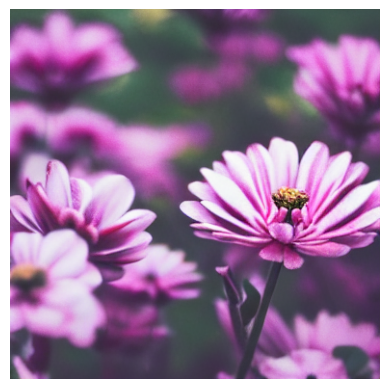

In [42]:
prompt = "a beautiful flower in a garden, high detail, 4k, realistic,noiseless ,bluryless"
image = pipe(
    prompt,
    num_inference_steps=20,
    height=384,
    width=384
).images[0]

import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis("off")
plt.show()